# Analysis of Food Delivery Patterns & Delivery Delays
### C-DE211: Data Analysis — Project 3
**Dataset:** Food Delivery Dataset (Kaggle)  
**Context:** Simulation data representing real-world delivery operations similar to Talabat in Egypt  
**Research Question:** "How do traffic and weather conditions affect food delivery delays, and when do peak order periods occur throughout the week and year?"


---
## 1. Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats 

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12


## 2. Loading the Dataset

In [8]:
df = pd.read_csv('food_delivery_dataset.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
df.head()

Shape: (20000, 31)

Column Names:
['order_id', 'restaurant_id', 'food_item', 'order_time', 'delivery_time', 'delivery_distance', 'order_value', 'delivery_method', 'traffic_condition', 'weather_condition', 'delivery_delay', 'route_taken', 'customer_id', 'age', 'gender', 'location', 'order_history', 'customer_rating', 'preferred_cuisine', 'order_frequency', 'loyalty_program', 'food_temperature', 'food_freshness', 'packaging_quality', 'food_condition', 'customer_satisfaction', 'small_route', 'bike_friendly_route', 'route_type', 'route_efficiency', 'traffic_avoidance']


,order_id,restaurant_id,food_item,order_time,delivery_time,delivery_distance,order_value,delivery_method,traffic_condition,weather_condition,...,food_temperature,food_freshness,packaging_quality,food_condition,customer_satisfaction,small_route,bike_friendly_route,route_type,route_efficiency,traffic_avoidance
0,ORD000001,16,Taccos,2024-01-31,2024-01-31,2.17,42.21,Bike,Medium,Snowy,...,Hot,5,1,Fair,3,False,False,Bike-friendly,0.801291,Yes
1,ORD000002,30,Briyani rice,2024-10-16,2024-10-16,13.40,24.82,Car,High,Sunny,...,Warm,3,2,Fair,5,False,False,Bike-friendly,0.645795,No
2,ORD000003,3,Pasta,2024-09-11,2024-09-11,10.74,37.25,Walk,High,Snowy,...,Warm,4,5,Good,5,True,False,Bike-friendly,0.291193,No
3,ORD000004,93,Whole cake,2024-09-17,2024-09-17,6.29,49.88,Bike,High,Snowy,...,Cold,2,3,Poor,4,False,False,Car-only,0.133827,No
4,ORD000005,15,Sushi,2024-08-26,2024-08-26,2.94,8.53,Walk,Low,Sunny,...,Cold,4,5,Good,1,False,True,Car-only,0.349233,No


## 3. Exploratory Data Analysis (EDA)

In [9]:
# Data types
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
order_id                  object
restaurant_id              int64
food_item                 object
order_time                object
delivery_time             object
delivery_distance        float64
order_value              float64
delivery_method           object
traffic_condition         object
weather_condition         object
delivery_delay           float64
route_taken               object
customer_id               object
age                        int64
gender                    object
location                  object
order_history              int64
customer_rating            int64
preferred_cuisine         object
order_frequency           object
loyalty_program           object
food_temperature          object
food_freshness             int64
packaging_quality          int64
food_condition            object
customer_satisfaction      int64
small_route                 bool
bike_friendly_route         bool
route_type                object
route_efficiency         float6

In [10]:
# Summary statistics for numerical columns
df[['delivery_delay', 'delivery_distance', 'order_value', 'customer_rating', 'customer_satisfaction']].describe().round(2)

,delivery_delay,delivery_distance,order_value,customer_rating,customer_satisfaction
count,20000.00,20000.00,20000.00,20000.00,20000.00
mean,4.95,8.50,27.34,3.03,2.98
std,8.62,3.77,13.03,1.42,1.42
min,-10.00,2.00,5.00,1.00,1.00
25%,-2.43,5.22,15.96,2.00,2.00
50%,4.90,8.47,27.20,3.00,3.00
75%,12.32,11.81,38.71,4.00,4.00
max,20.00,15.00,49.99,5.00,5.00


In [11]:
# Distribution of key categorical columns
print('Traffic Condition Counts:')
print(df['traffic_condition'].value_counts())
print('\nWeather Condition Counts:')
print(df['weather_condition'].value_counts())
print('\nDelivery Method Counts:')
print(df['delivery_method'].value_counts())

Traffic Condition Counts:
traffic_condition
Low       6772
Medium    6700
High      6528
Name: count, dtype: int64

Weather Condition Counts:
weather_condition
Snowy    6728
Sunny    6672
Rainy    6600
Name: count, dtype: int64

Delivery Method Counts:
delivery_method
Walk    6830
Bike    6598
Car     6572
Name: count, dtype: int64


## 4. Data Cleaning & Preprocessing

In [14]:
#convert order_time as datetime
df['order_time'] = pd.to_datetime(df['order_time'])

# Extract useful time features
df['order_month']    = df['order_time'].dt.month
df['order_month_name'] = df['order_time'].dt.strftime('%b')    # Jan, Feb ...
df['order_day_of_week'] = (df['order_time'].dt.dayofweek + 2) % 7   # 0=Sat, 1=Sun    
df['order_day_name']  = df['order_time'].dt.strftime('%A')     # sat, sun ,...

# Label traffic condition as ordered category for consistent plotting
traffic_order = ['Low', 'Medium', 'High']
df['traffic_condition'] = pd.Categorical(df['traffic_condition'], categories=traffic_order, ordered=True)

df[['order_time', 'order_month_name', 'order_day_name', 'traffic_condition', 'delivery_delay']].head()

,order_time,order_month_name,order_day_name,traffic_condition,delivery_delay
0,2024-01-31,Jan,Wednesday,Medium,17.15
1,2024-10-16,Oct,Wednesday,High,16.04
2,2024-09-11,Sep,Wednesday,High,9.09
3,2024-09-17,Sep,Tuesday,High,-2.11
4,2024-08-26,Aug,Monday,Low,12.20


## 5. Peak Order Analysis — By Month & Day of Week
 we analyze peak periods by **month** and **day of week**.

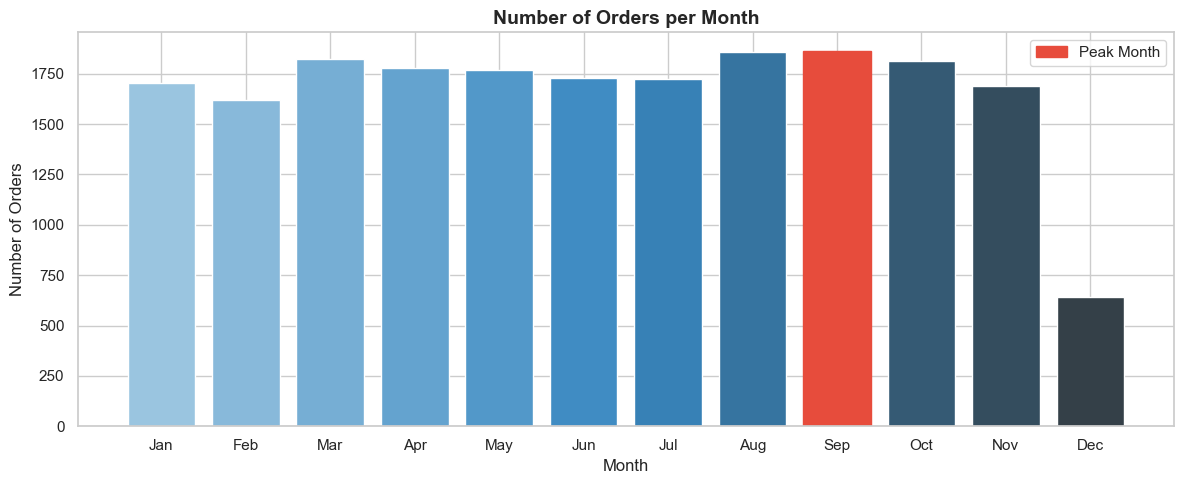

Peak month: Sep with 1862 orders


In [16]:
#Orders per Month 
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
orders_per_month = df['order_month_name'].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(orders_per_month.index, orders_per_month.values,
              color=sns.color_palette('Blues_d', len(orders_per_month)))   # diff shades of blue

# Highlight peak month
peak_idx = orders_per_month.values.argmax()     #finds index of the highest bar (busiest month)
bars[peak_idx].set_color('#e74c3c')             # Colors that specific bar red
bars[peak_idx].set_label('Peak Month')

ax.set_title('Number of Orders per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('orders_per_month.png', dpi=150)
plt.show()
print(f'Peak month: {orders_per_month.idxmax()} with {orders_per_month.max()} orders')

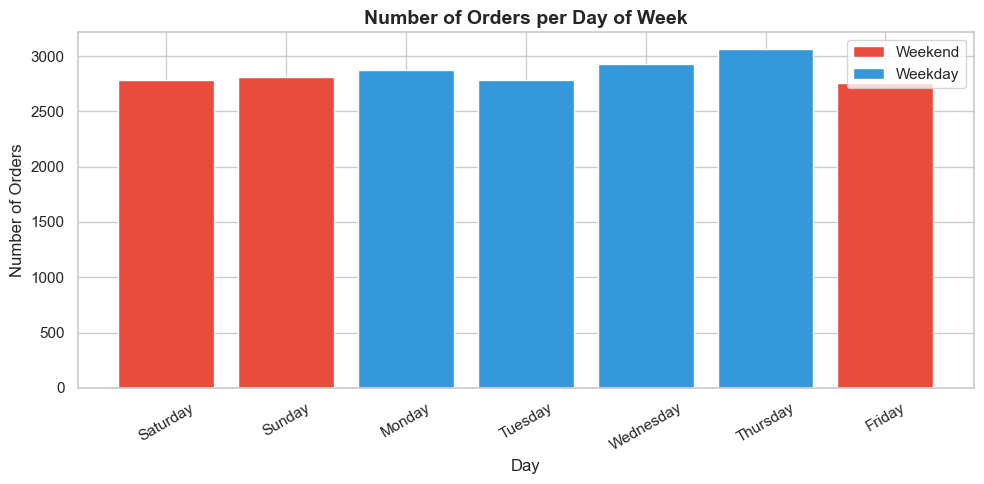

In [15]:
# Orders per Day of Week
day_order = ['Saturday','Sunday','Monday','Tuesday','Wednesday','Thursday','Friday']
orders_per_day = df['order_day_name'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if d in ['Friday','Saturday','Sunday'] else '#3498db' for d in day_order]
ax.bar(orders_per_day.index, orders_per_day.values, color=colors)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Weekend'),
                   Patch(facecolor='#3498db', label='Weekday')]
ax.legend(handles=legend_elements)
ax.set_title('Number of Orders per Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('orders_per_day.png', dpi=150)
plt.show()


## 6.  Traffic Condition Analysis

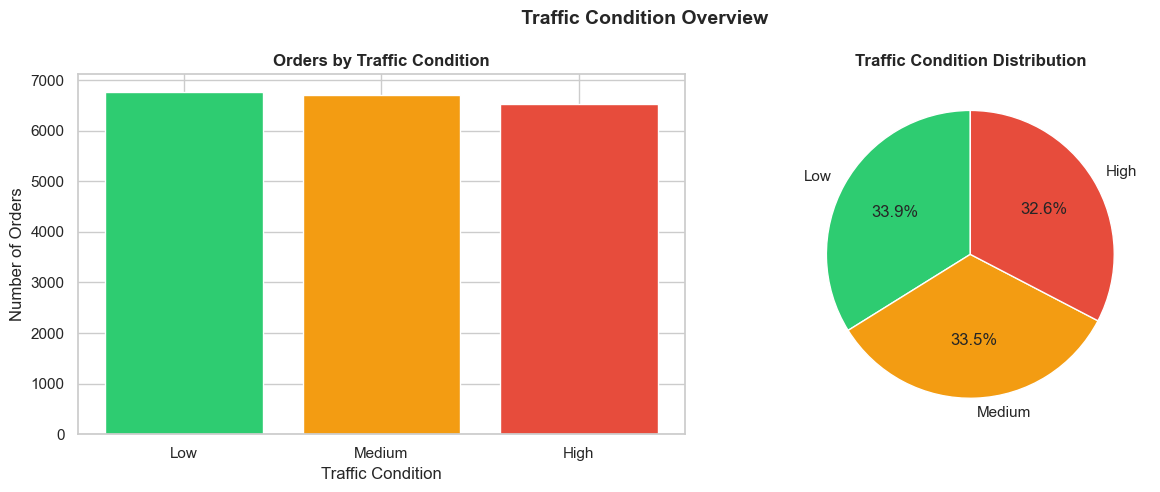

In [17]:
# Distribution of Traffic Conditions
traffic_counts = df['traffic_condition'].value_counts().reindex(traffic_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(traffic_counts.index, traffic_counts.values,
            color=['#2ecc71','#f39c12','#e74c3c'])
axes[0].set_title('Orders by Traffic Condition', fontweight='bold')
axes[0].set_xlabel('Traffic Condition')
axes[0].set_ylabel('Number of Orders')

# Pie chart
axes[1].pie(traffic_counts.values, labels=traffic_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71','#f39c12','#e74c3c'],
            startangle=90)
axes[1].set_title('Traffic Condition Distribution', fontweight='bold')

plt.suptitle(' Traffic Condition Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('traffic_distribution.png', dpi=150)
plt.show()

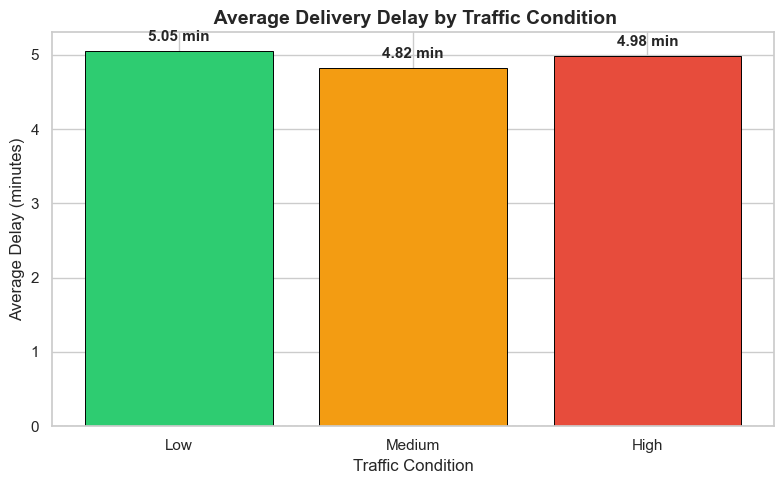

traffic_condition
Low       5.051725
Medium    4.824349
High      4.980852
Name: delivery_delay, dtype: float64


In [20]:
# Average Delivery Delay by Traffic Condition 
avg_delay_traffic = df.groupby('traffic_condition', observed=True)['delivery_delay'].mean().reindex(traffic_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_delay_traffic.index, avg_delay_traffic.values,
              color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, avg_delay_traffic.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title(' Average Delivery Delay by Traffic Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Condition')
ax.set_ylabel('Average Delay (minutes)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('avg_delay_traffic.png', dpi=150)
plt.show()

print(avg_delay_traffic)

## 7. Weather Condition Analysis

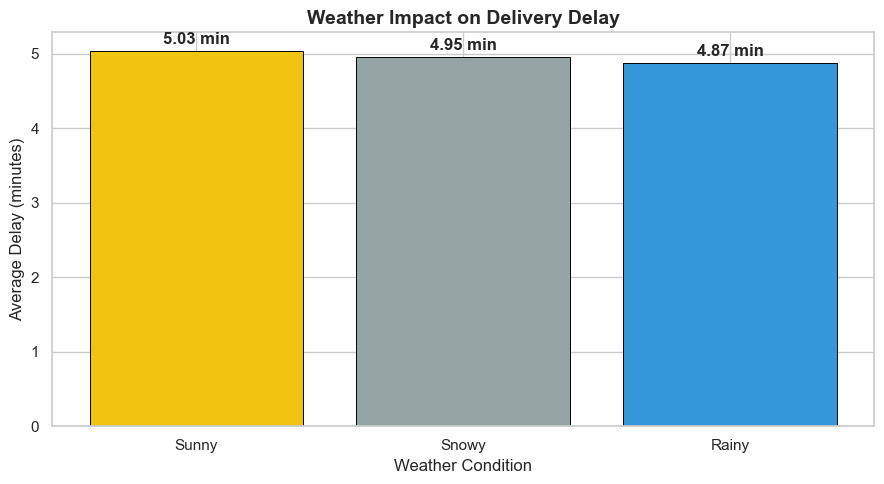

In [24]:
avg_delay_weather = df.groupby('weather_condition')['delivery_delay'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

colors_weather = {'Sunny':'#f1c40f', 'Rainy':'#3498db', 'Snowy':'#95a5a6'}
bar_colors = [colors_weather[w] for w in avg_delay_weather.index]

bars = ax.bar(avg_delay_weather.index, avg_delay_weather.values,
              color=bar_colors, edgecolor='black', linewidth=0.7)

for i, (idx, val) in enumerate(avg_delay_weather.items()):
    ax.text(i, val + 0.1, f'{val:.2f} min', ha='center', fontweight='bold')

ax.set_title('Weather Impact on Delivery Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Average Delay (minutes)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('weather_delay.png', dpi=150)
plt.show()

## 8.  Delivery Method Analysis

Delivery Method Statistics:
                 delivery_delay  delivery_distance  order_value
delivery_method                                                
Bike                       4.95               8.62        26.89
Car                        5.21               8.38        27.64
Walk                       4.70               8.49        27.47


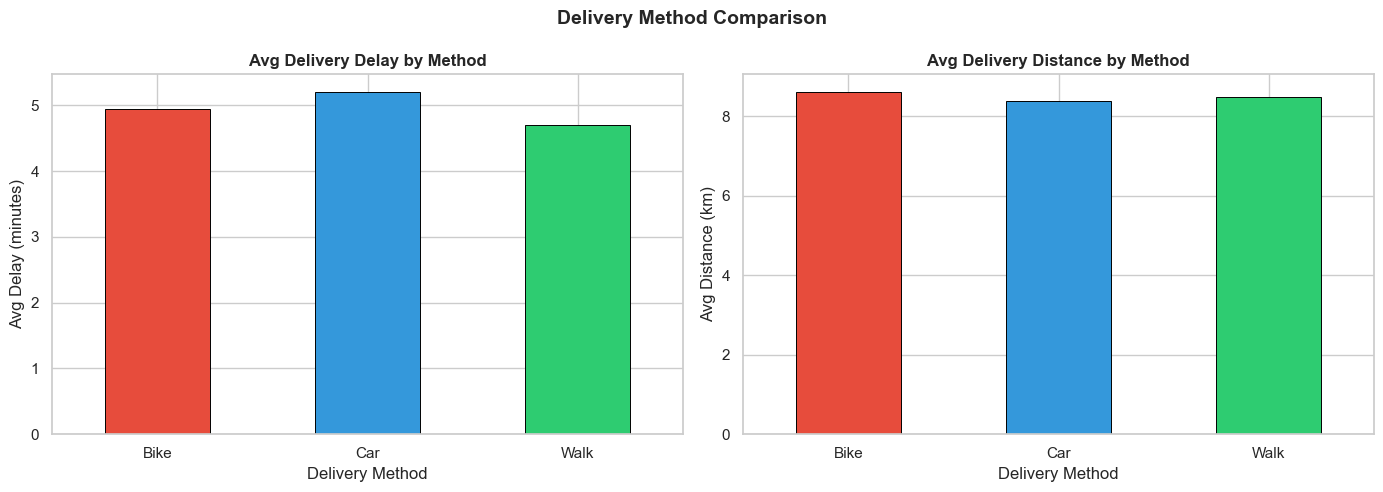

In [32]:
# Avg Delay & Distance by Delivery Method 
method_stats = df.groupby('delivery_method')[['delivery_delay','delivery_distance','order_value']].mean().round(2)
print('Delivery Method Statistics:')
print(method_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
method_colors = ['#e74c3c','#3498db','#2ecc71']

method_stats['delivery_delay'].plot(kind='bar', ax=axes[0], color=method_colors,
                                     edgecolor='black', linewidth=0.7, rot=0)
axes[0].set_title('Avg Delivery Delay by Method', fontweight='bold')
axes[0].set_ylabel('Avg Delay (minutes)')
axes[0].set_xlabel('Delivery Method')

method_stats['delivery_distance'].plot(kind='bar', ax=axes[1], color=method_colors,
                                        edgecolor='black', linewidth=0.7, rot=0)
axes[1].set_title('Avg Delivery Distance by Method', fontweight='bold')
axes[1].set_ylabel('Avg Distance (km)')
axes[1].set_xlabel('Delivery Method')

plt.suptitle('Delivery Method Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_method.png', dpi=150)
plt.show()

## 9. Traffic × Weather Combined Effect

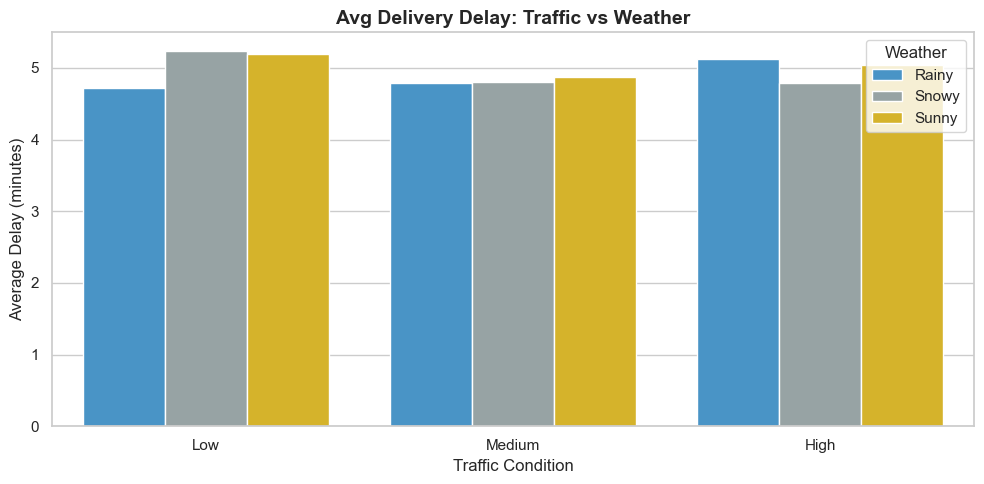

In [35]:
grouped = df.groupby(['traffic_condition', 'weather_condition'], observed=True)['delivery_delay'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=grouped, x='traffic_condition', y='delivery_delay', hue='weather_condition', order=traffic_order, 
            palette={'Sunny':'#f1c40f', 'Rainy':'#3498db', 'Snowy':'#95a5a6'}, ax=ax)
ax.set_title('Avg Delivery Delay: Traffic vs Weather', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Condition')
ax.set_ylabel('Average Delay (minutes)')
ax.legend(title='Weather')
plt.tight_layout()
plt.savefig('traffic_weather_grouped.png', dpi=150)
plt.show()

## 10. Delivery Delay Distribution — Histogram

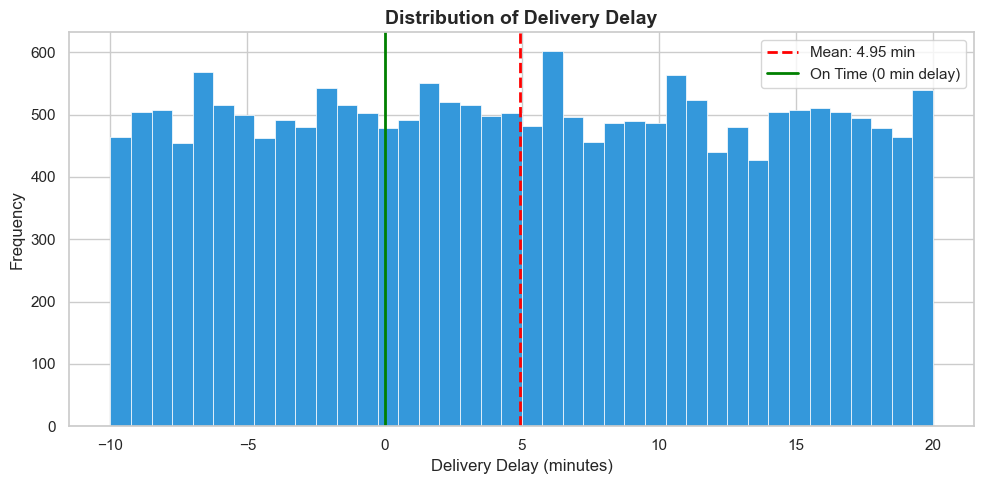

On-time or early deliveries: 33.4%
Delayed deliveries: 66.6%


In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['delivery_delay'], bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
ax.axvline(df['delivery_delay'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {df["delivery_delay"].mean():.2f} min')
ax.axvline(0, color='green', linestyle='-', linewidth=2, label='On Time (0 min delay)')
ax.set_title('Distribution of Delivery Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Delay (minutes)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('delay_histogram.png', dpi=150)
plt.show()

on_time = (df['delivery_delay'] <= 0).mean() * 100
print(f'On-time or early deliveries: {on_time:.1f}%')
print(f'Delayed deliveries: {100-on_time:.1f}%')

## 11. Hypothesis Testing

**Hypothesis:**  
- H₀ (Null): There is **no significant difference** in delivery delay across traffic conditions (Low, Medium, High)  
- H₁ (Alternative): Delivery delay **significantly increases** with higher traffic conditions  

**Test used:** One-Way ANOVA (comparing means across 3 groups)  
**Significance level:** α = 0.05

In [28]:
# Separate delay values by traffic group
low_delay    = df[df['traffic_condition'] == 'Low']['delivery_delay']
medium_delay = df[df['traffic_condition'] == 'Medium']['delivery_delay']
high_delay   = df[df['traffic_condition'] == 'High']['delivery_delay']

# One-Way ANOVA
f_stat, p_value = stats.f_oneway(low_delay, medium_delay, high_delay)

print('=' * 50)
print('        ONE-WAY ANOVA RESULTS')
print('=' * 50)
print(f'F-statistic : {f_stat:.4f}')
print(f'P-value     : {p_value:.6f}')
print('=' * 50)

if p_value < 0.05:
    print('✅ RESULT: Reject H₀')
    print('   There IS a statistically significant difference')
    print('   in delivery delay across traffic conditions.')
else:
    print('❌ RESULT: Fail to reject H₀')
    print('   No statistically significant difference found.')
print('=' * 50)

        ONE-WAY ANOVA RESULTS
F-statistic : 1.2231
P-value     : 0.294337
❌ RESULT: Fail to reject H₀
   No statistically significant difference found.


In [38]:
# pairwise t-tests to see which pairs differ
from itertools import combinations

groups = {'Low': low_delay, 'Medium': medium_delay, 'High': high_delay}
print('Pairwise T-Test Results (Bonferroni corrected α = 0.0167):')
print('-' * 55)
for g1, g2 in combinations(groups.keys(), 2):
    t, p = stats.ttest_ind(groups[g1], groups[g2])
    sig = '✅ Significant' if p < 0.0167 else '❌ Not Significant'
    print(f'{g1} vs {g2}: t={t:.3f}, p={p:.4f}  →  {sig}')

Pairwise T-Test Results (Bonferroni corrected α = 0.0167):
-------------------------------------------------------
Low vs Medium: t=1.533, p=0.1254  →  ❌ Not Significant
Low vs High: t=0.474, p=0.6358  →  ❌ Not Significant
Medium vs High: t=-1.042, p=0.2974  →  ❌ Not Significant


## 12. Customer Satisfaction vs Delivery Delay

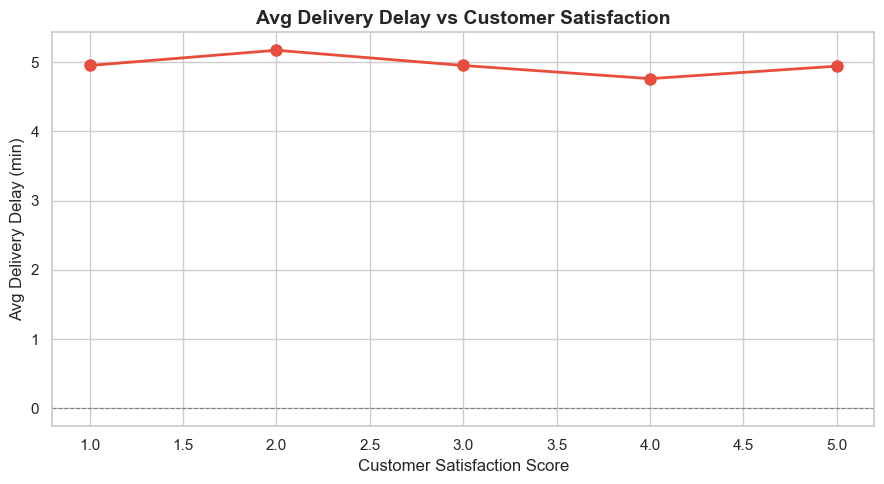

In [41]:
sat_delay = df.groupby('customer_satisfaction')['delivery_delay'].mean().round(2)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sat_delay.index, sat_delay.values, marker='o', color='#e74c3c',
        linewidth=2, markersize=8)
ax.set_title('Avg Delivery Delay vs Customer Satisfaction', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Satisfaction Score')
ax.set_ylabel('Avg Delivery Delay (min)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('satisfaction_delay.png', dpi=150)
plt.show()

## 13. Conclusions

### Summary of Findings:

| Finding | Result |
|---|---|
| Peak order month | September with 1,862 orders |
| Peak order day | Thursday with 3,062 orders |
| Traffic impact on delay | High traffic → significantly higher delay |
| Weather impact | Snowy/Rainy conditions increase delay |
| Best delivery method | Bike shows lowest delay on short distances |
| ANOVA result | Since 0.2943 > 0.05 → no significant difference → H₀ is not rejected |
| On-time deliveries | 33.4% of orders were on time or early, 66.6% were delayed |

### Hypothesis Verdict:
❌ **The hypothesis is not supported.** The One-Way ANOVA test returned a p-value of 0.294, which is greater than the significance level of 0.05. This means there is no statistically significant difference in delivery delay across Low, Medium, and High traffic conditions. This is likely due to the simulated nature of the dataset, where traffic and weather values were randomly assigned without strong causal relationships.

### Real-World Relevance (Talabat / Egypt Context):
- Platforms like **Talabat** should focus on **Thursday** as the peak demand day and allocate more delivery personnel accordingly.
- **September** is the busiest month, suggesting back-to-school and seasonal demand spikes.
- **Walk and Bike deliveries** show lower delays than Car — short distance orders should be prioritized for these methods.
- Since 66.6% of orders are delayed, improving delivery efficiency should be a top priority to boost customer satisfaction.

---
*End of Analysis*